# Capítulo 6, Sección 6.3 — Ejemplo 5  - Juan José Salazar Bedoya - Cristian Camilo Victoria Parra
## EDPs de alta dimensión / PINN para Black–Scholes de una opción basket

Este cuaderno replica computacionalmente el **Ejemplo 5** de la Sección 6.3: resolver una EDP de alta dimensión con una PINN.  
El ejemplo del libro usa como caso guía el precio de una opción europea tipo *basket*, cuya función de precio $u(s,t)$ satisface una ecuación de Black–Scholes de dimensión $d$.

La formulación del libro es

$
\frac{\partial u}{\partial t}
+\frac12 \sum_{i,j=1}^{d}
\rho_{ij}\sigma_i\sigma_j s_i s_j
\frac{\partial^2 u}{\partial s_i\partial s_j}
+r\sum_{i=1}^{d}s_i\frac{\partial u}{\partial s_i}
-r u=0,
$

con condición terminal

$
u(s,T)=\max\left(\frac1d\sum_{i=1}^{d}s_i-K,0\right).
$

Aquí implementamos una versión **ejecutable en Colab**. Por defecto usamos $d=10$ para que corra en minutos; si quiere acercarse al experimento mencionado por el libro, puede cambiar `D = 50`, pero eso exige más tiempo y GPU.  
Como una red neuronal no necesita una malla cartesiana completa, los puntos de entrenamiento se muestrean aleatoriamente en el espacio $(s,t)$. Eso es precisamente la gracia: evitar que el costo crezca como $N^d$, esa pequeña tragedia llamada maldición de la dimensionalidad.

## 1. Librerías y dispositivo

Usamos PyTorch porque necesitamos diferenciación automática respecto a las coordenadas $s_1,\ldots,s_d,t$.  
La red aprenderá la función normalizada

$
v(s,t)=\frac{u(s,t)}{K},
$

para que los valores sean de orden $1$, no de orden $100$.

In [ ]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| dispositivo:", device)

PyTorch: 2.11.0+cpu | dispositivo: cpu


## 2. Parámetros del problema

- `D`: dimensión del problema, es decir, número de activos.
- `K_STRIKE`: precio de ejercicio.
- `T`: vencimiento.
- `R`: tasa libre de riesgo.
- `SIGMA_VALUE`: volatilidad de los activos.
- `USE_FULL_CORRELATION`: si es `False`, se usa $\rho=I$, lo que evita derivadas mixtas y permite escalar mejor. Si es `True`, se activa una matriz de correlación equicorrelada, pero eso es mucho más costoso porque aparecen derivadas $\partial^2u/\partial s_i\partial s_j$.

El libro escribe la ecuación con correlaciones $\rho_{ij}$. En este notebook dejamos ambas posibilidades, pero la configuración por defecto es diagonal para que Colab no se convierta en calefactor.

In [ ]:
# Dimensión. Cambie a 50 para una prueba más cercana al ejemplo mencionado en el libro.
D = 50

# Parámetros financieros.
K_STRIKE = 100.0
T = 1.0
R = 0.05
SIGMA_VALUE = 0.20

# Dominio computacional truncado para s_i.
# La ecuación vive en R_+^d, pero para entrenar una PINN se trabaja en una caja finita.
S_LOW = 1e-3
S_HIGH = 200.0

# Correlación.
USE_FULL_CORRELATION = False
RHO_OFFDIAG = 0.25

# Hiperparámetros de muestreo.
N_F = 1024 if device.type == "cuda" else 384      # puntos interiores para residuo de EDP
N_T = 1024 if device.type == "cuda" else 384      # puntos de condición terminal
N_LOW = 256 if device.type == "cuda" else 128     # frontera baja: todos los activos cerca de 0
N_HIGH = 256 if device.type == "cuda" else 128    # frontera alta: todos los activos cerca de S_HIGH

# Entrenamiento.
N_STEPS = 5000 if device.type == "cuda" else 1600
PRINT_EVERY = max(200, N_STEPS // 10)
LR = 1e-3

# Pesos de pérdida.
LAMBDA_F = 1.0
LAMBDA_T = 50.0
LAMBDA_LOW = 10.0
LAMBDA_HIGH = 5.0

print(f"D = {D}, N_STEPS = {N_STEPS}, full correlation = {USE_FULL_CORRELATION}")

D = 50, N_STEPS = 1600, full correlation = False


## 3. Funciones auxiliares

La condición terminal normalizada es

$
v(s,T)=\frac{1}{K}\max\left(\frac1d\sum_{i=1}^d s_i-K,0\right).
$

También definimos un muestreador de activos. Para no desperdiciar todos los puntos en regiones enormes e inútiles, muestreamos $s_i$ de manera log-uniforme entre valores bajos y altos. Esto concentra más puntos alrededor de escalas relevantes para el strike.

In [ ]:
sigma_vec = torch.full((1, D), SIGMA_VALUE, dtype=torch.float32, device=device)

if USE_FULL_CORRELATION:
    rho_np = np.full((D, D), RHO_OFFDIAG, dtype=np.float32)
    np.fill_diagonal(rho_np, 1.0)
else:
    rho_np = np.eye(D, dtype=np.float32)

rho = torch.tensor(rho_np, dtype=torch.float32, device=device)

def payoff_torch(s):
    """Payoff normalizado: max(mean(s)-K,0)/K."""
    basket = s.mean(dim=1, keepdim=True)
    return torch.relu(basket - K_STRIKE) / K_STRIKE

def payoff_np(s):
    """Versión NumPy del payoff normalizado."""
    basket = s.mean(axis=1, keepdims=True)
    return np.maximum(basket - K_STRIKE, 0.0) / K_STRIKE

def sample_assets(n, low=35.0, high=S_HIGH):
    """
    Muestreo log-uniforme en [low, high]^D.
    Esto evita que los puntos se amontonen demasiado lejos del strike.
    """
    z = np.random.rand(n, D)
    log_s = np.log(low) + (np.log(high) - np.log(low)) * z
    return np.exp(log_s).astype(np.float32)

def to_tensor(a, requires_grad=False):
    t = torch.tensor(a, dtype=torch.float32, device=device)
    return t.requires_grad_(requires_grad)

def make_time(n, value=None, requires_grad=False):
    if value is None:
        a = np.random.rand(n, 1).astype(np.float32) * T
    else:
        a = np.full((n, 1), value, dtype=np.float32)
    return to_tensor(a, requires_grad=requires_grad)

def far_field_asymptotic_torch(s, t):
    """
    Frontera alta aproximada: si todos los activos están muy por encima de K,
    la opción basket se comporta aproximadamente como
    mean(s)/K - exp(-r(T-t)).
    Es una condición suave auxiliar, no una solución exacta.
    """
    tau = T - t
    return torch.relu(s.mean(dim=1, keepdim=True)/K_STRIKE - torch.exp(-R*tau))

## 4. Visualización del payoff terminal

No podemos visualizar una función de $d=10$ o $d=50$ dimensiones completa.  
Lo que sí podemos hacer es mirar una sección: variamos $s_1$ y dejamos los demás activos en $K$.

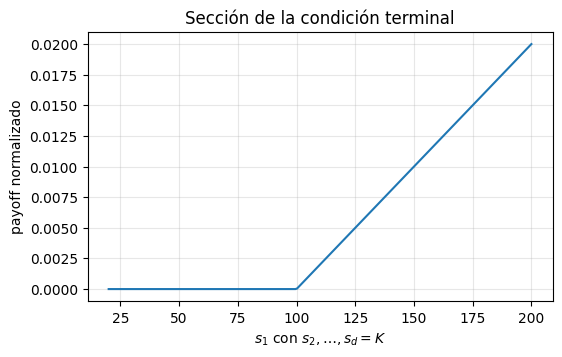

In [ ]:
s1_grid = np.linspace(20, S_HIGH, 250, dtype=np.float32)
S_section = np.full((len(s1_grid), D), K_STRIKE, dtype=np.float32)
S_section[:, 0] = s1_grid
pay_section = payoff_np(S_section).ravel()

plt.figure(figsize=(6, 3.5))
plt.plot(s1_grid, pay_section)
plt.xlabel(r"$s_1$ con $s_2,\ldots,s_d=K$")
plt.ylabel(r"payoff normalizado")
plt.title("Sección de la condición terminal")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Red neuronal PINN

La red recibe

$
(s_1,\ldots,s_d,t)
$

y devuelve

$
\widehat v(s,t)\approx \frac{u(s,t)}{K}.
$

Dentro de la red normalizamos entradas para que $s_i/K$ y $t/T$ tengan escalas razonables. Eso ayuda bastante al entrenamiento; una red que recibe números entre 0 y 200 sin normalizar también entrena, pero con esa elegancia torpe de quien corre con botas mojadas.

In [ ]:
class MLP(nn.Module):
    def __init__(self, d, width=96, depth=4):
        super().__init__()
        dims = [d + 1] + [width] * depth + [1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, s, t):
        # Normalización diferenciable: autograd seguirá calculando derivadas respecto a s y t.
        s_norm = s / K_STRIKE - 1.0
        t_norm = 2.0 * t / T - 1.0
        x = torch.cat([s_norm, t_norm], dim=1)
        return self.net(x)

net = MLP(D).to(device)
n_params = sum(p.numel() for p in net.parameters())
print("Parámetros entrenables:", n_params)

Parámetros entrenables: 33025


## 6. Residuo de Black–Scholes por autograd

Para un punto interior, el residuo es

$
\mathcal R(s,t)
=
\widehat v_t
+\frac12\sum_{i,j=1}^d
\rho_{ij}\sigma_i\sigma_j s_i s_j
\widehat v_{s_i s_j}
+r\sum_{i=1}^d s_i \widehat v_{s_i}
-r\widehat v.
$

Si $\rho=I$, solo necesitamos las derivadas segundas diagonales $\widehat v_{s_i s_i}$.  
Si `USE_FULL_CORRELATION=True`, el código calcula también derivadas mixtas. Eso es fiel a la fórmula completa, pero computacionalmente más pesado.

In [ ]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]

def black_scholes_residual(model, s, t):
    """
    Residuo de Black-Scholes para v = u/K.
    s: tensor (N,D) con requires_grad=True.
    t: tensor (N,1) con requires_grad=True.
    """
    v = model(s, t)
    v_t = grad(v, t)
    v_s = grad(v, s)  # (N,D)

    drift = R * torch.sum(s * v_s, dim=1, keepdim=True)

    if not USE_FULL_CORRELATION:
        # Caso independiente: rho = I. Solo derivadas segundas diagonales.
        diffusion = torch.zeros_like(v)
        for i in range(D):
            v_si = v_s[:, i:i+1]
            v_sisi = grad(v_si, s)[:, i:i+1]
            diffusion = diffusion + 0.5 * (SIGMA_VALUE**2) * (s[:, i:i+1]**2) * v_sisi
    else:
        # Caso completo: incluye derivadas mixtas. Recomendado solo para D pequeño.
        diffusion = torch.zeros_like(v)
        for i in range(D):
            v_si = v_s[:, i:i+1]
            hess_row_i = grad(v_si, s)  # columnas j: v_{s_i s_j}
            for j in range(D):
                coef = 0.5 * rho[i, j] * sigma_vec[0, i] * sigma_vec[0, j]
                diffusion = diffusion + coef * s[:, i:i+1] * s[:, j:j+1] * hess_row_i[:, j:j+1]

    return v_t + diffusion + drift - R * v

## 7. Construcción de la pérdida

La pérdida contiene:

$
L = \lambda_f L_f+\lambda_T L_T+\lambda_{\text{low}}L_{\text{low}}+\lambda_{\text{high}}L_{\text{high}}.
$

- $L_f$: residual de Black–Scholes en puntos interiores.
- $L_T$: condición terminal del payoff.
- $L_{\text{low}}$: frontera baja aproximada cuando todos los activos están cerca de cero.
- $L_{\text{high}}$: frontera alta asintótica cuando todos los activos están muy por encima del strike.

La condición terminal es la condición esencial. Las fronteras baja y alta son estabilizadores porque la EDP original vive en $\mathbb R_+^d$, pero el computador, aunque se crea especial, no entrena en infinitos.

In [ ]:
def loss_terms(model):
    # Puntos interiores para la EDP.
    s_f_np = sample_assets(N_F)
    s_f = to_tensor(s_f_np, requires_grad=True)
    t_f = make_time(N_F, requires_grad=True)

    r_f = black_scholes_residual(model, s_f, t_f)
    loss_f = torch.mean(r_f**2)

    # Condición terminal t = T.
    s_T_np = sample_assets(N_T)
    s_T = to_tensor(s_T_np, requires_grad=False)
    t_T = make_time(N_T, value=T, requires_grad=False)
    v_T_pred = model(s_T, t_T)
    v_T_true = payoff_torch(s_T)
    loss_T = torch.mean((v_T_pred - v_T_true)**2)

    # Frontera baja: todos los activos cerca de cero => opción aproximadamente sin valor.
    s_low = torch.full((N_LOW, D), S_LOW, dtype=torch.float32, device=device)
    t_low = make_time(N_LOW, requires_grad=False)
    loss_low = torch.mean(model(s_low, t_low)**2)

    # Frontera alta diagonal: todos los activos en S_HIGH.
    s_high = torch.full((N_HIGH, D), S_HIGH, dtype=torch.float32, device=device)
    t_high = make_time(N_HIGH, requires_grad=False)
    v_high_true = far_field_asymptotic_torch(s_high, t_high)
    loss_high = torch.mean((model(s_high, t_high) - v_high_true)**2)

    total = (
        LAMBDA_F * loss_f
        + LAMBDA_T * loss_T
        + LAMBDA_LOW * loss_low
        + LAMBDA_HIGH * loss_high
    )
    return total, loss_f, loss_T, loss_low, loss_high

## 8. Entrenamiento con Adam

En cada iteración se remuestrean puntos interiores y terminales.  
Esto es una ventaja de los métodos sin malla: no dependemos de una grilla fija de tamaño $N^d$.

In [ ]:
optimizer = torch.optim.Adam(net.parameters(), lr=LR)

hist = {
    "total": [],
    "pde": [],
    "terminal": [],
    "low": [],
    "high": [],
}

t0 = time.time()

for it in range(N_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    loss, loss_f, loss_T, loss_low, loss_high = loss_terms(net)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=10.0)
    optimizer.step()

    hist["total"].append(float(loss.detach().cpu()))
    hist["pde"].append(float((LAMBDA_F * loss_f).detach().cpu()))
    hist["terminal"].append(float((LAMBDA_T * loss_T).detach().cpu()))
    hist["low"].append(float((LAMBDA_LOW * loss_low).detach().cpu()))
    hist["high"].append(float((LAMBDA_HIGH * loss_high).detach().cpu()))

    if it % PRINT_EVERY == 0:
        print(
            f"it={it:5d} | total={hist['total'][-1]:.3e} | "
            f"pde={hist['pde'][-1]:.3e} | T={hist['terminal'][-1]:.3e} | "
            f"low={hist['low'][-1]:.3e} | high={hist['high'][-1]:.3e}"
        )

print(f"Tiempo de entrenamiento: {time.time() - t0:.1f} s")

it=    0 | total=1.814e+01 | pde=3.498e-02 | T=5.854e+00 | low=1.819e+00 | high=1.044e+01
it=  200 | total=1.379e-02 | pde=5.301e-04 | T=1.196e-02 | low=9.741e-04 | high=3.299e-04
it=  400 | total=5.993e-03 | pde=2.468e-04 | T=5.313e-03 | low=2.858e-04 | high=1.482e-04
it=  600 | total=6.769e-03 | pde=1.554e-04 | T=5.587e-03 | low=9.908e-04 | high=3.572e-05
it=  800 | total=4.058e-03 | pde=8.774e-05 | T=3.418e-03 | low=3.869e-04 | high=1.660e-04
it= 1000 | total=2.949e-03 | pde=8.773e-05 | T=2.467e-03 | low=2.912e-04 | high=1.024e-04
it= 1200 | total=4.380e-03 | pde=5.926e-05 | T=2.889e-03 | low=1.133e-03 | high=2.991e-04
it= 1400 | total=3.322e-03 | pde=5.045e-05 | T=2.864e-03 | low=3.448e-04 | high=6.269e-05
it= 1600 | total=1.345e-03 | pde=4.331e-05 | T=1.079e-03 | low=1.056e-04 | high=1.172e-04
Tiempo de entrenamiento: 370.3 s


## 9. Visualización del historial de pérdida

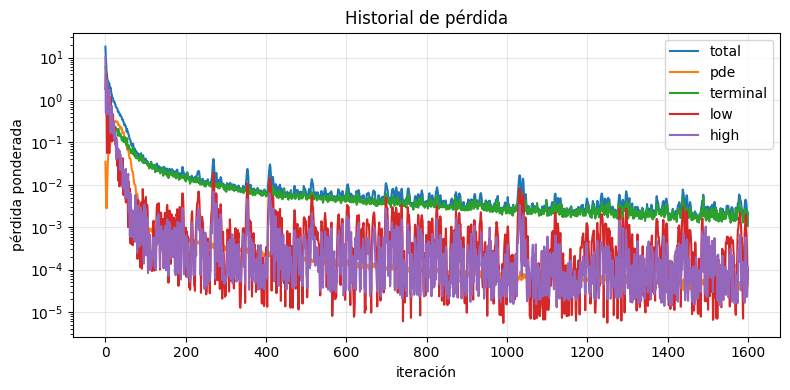

In [ ]:
plt.figure(figsize=(8, 4))
for key, values in hist.items():
    plt.semilogy(values, label=key)
plt.xlabel("iteración")
plt.ylabel("pérdida ponderada")
plt.title("Historial de pérdida")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Referencia Monte Carlo

Para validar una opción europea basket, podemos usar Monte Carlo bajo la medida neutral al riesgo:

$
S_i(T)=S_i(t)\exp\left((r-\tfrac12\sigma_i^2)(T-t)+\sigma_i\sqrt{T-t}\,Z_i\right),
$

con $Z$ normal correlacionado. El precio es

$
u(s,t)=e^{-r(T-t)}
\mathbb E\left[
\max\left(\frac1d\sum_{i=1}^d S_i(T)-K,0\right)
\right].
$

Monte Carlo no entrena la PINN; solo sirve como referencia numérica externa.

In [ ]:
def mc_basket_call_price(s0, t0=0.0, n_paths=80_000, seed=1234):
    """
    Precio Monte Carlo de la opción basket.
    s0: array shape (D,)
    Devuelve precio no normalizado.
    """
    rng = np.random.default_rng(seed)
    s0 = np.asarray(s0, dtype=np.float64).reshape(1, D)
    tau = max(T - float(t0), 0.0)
    if tau == 0.0:
        return float(np.maximum(s0.mean() - K_STRIKE, 0.0)), 0.0

    if USE_FULL_CORRELATION:
        L_chol = np.linalg.cholesky(rho_np)
        z = rng.standard_normal((n_paths, D)) @ L_chol.T
    else:
        z = rng.standard_normal((n_paths, D))

    sigma = SIGMA_VALUE
    ST = s0 * np.exp((R - 0.5 * sigma**2) * tau + sigma * np.sqrt(tau) * z)
    payoff = np.maximum(ST.mean(axis=1) - K_STRIKE, 0.0)
    disc_payoff = np.exp(-R * tau) * payoff
    price = disc_payoff.mean()
    se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return float(price), float(se)

@torch.no_grad()
def pinn_price(s0, t0=0.0):
    s = torch.tensor(np.asarray(s0, dtype=np.float32).reshape(1, D), device=device)
    t = torch.tensor([[t0]], dtype=torch.float32, device=device)
    v = net(s, t).item()
    return K_STRIKE * v

s0 = np.full(D, K_STRIKE, dtype=np.float64)

price_pinn = pinn_price(s0, 0.0)
price_mc, se_mc = mc_basket_call_price(s0, 0.0, n_paths=80_000)

print(f"Precio PINN en ATM basket:       {price_pinn:.6f}")
print(f"Precio Monte Carlo:              {price_mc:.6f} ± {1.96*se_mc:.6f} (IC 95%)")
print(f"Error absoluto:                  {abs(price_pinn - price_mc):.6f}")
print(f"Error relativo:                  {abs(price_pinn - price_mc)/max(price_mc, 1e-12):.3%}")

Precio PINN en ATM basket:       4.027058
Precio Monte Carlo:              4.935384 ± 0.019177 (IC 95%)
Error absoluto:                  0.908326
Error relativo:                  18.404%


## 11. Comparación en una sección unidimensional

Como no podemos graficar toda la función de precio en $d$ dimensiones, miramos una sección:

$
s_2=\cdots=s_d=K,
\qquad
s_1 \text{ variable}.
$

Comparamos la PINN contra Monte Carlo. La referencia Monte Carlo tiene ruido, así que no espere una línea perfecta; tampoco somos magos, aunque el gráfico intente vender esa fantasía.

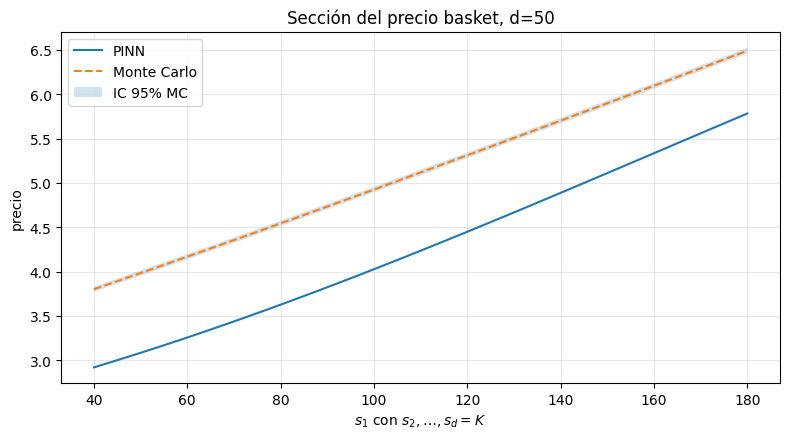

In [ ]:
def mc_curve_vary_s1(s1_values, n_paths=30_000, seed=2026):
    """
    Curva MC vectorizada: varía s1 y deja los demás activos en K.
    Usa los mismos shocks normales para todos los puntos de la curva.
    """
    rng = np.random.default_rng(seed)
    tau = T

    if USE_FULL_CORRELATION:
        L_chol = np.linalg.cholesky(rho_np)
        z = rng.standard_normal((n_paths, D)) @ L_chol.T
    else:
        z = rng.standard_normal((n_paths, D))

    sigma = SIGMA_VALUE
    growth = np.exp((R - 0.5 * sigma**2) * tau + sigma * np.sqrt(tau) * z)  # (paths,D)

    prices = []
    ses = []
    for s1 in s1_values:
        s0 = np.full(D, K_STRIKE, dtype=np.float64)
        s0[0] = s1
        ST = s0.reshape(1, D) * growth
        payoff = np.maximum(ST.mean(axis=1) - K_STRIKE, 0.0)
        disc_payoff = np.exp(-R * tau) * payoff
        prices.append(disc_payoff.mean())
        ses.append(disc_payoff.std(ddof=1) / np.sqrt(n_paths))
    return np.array(prices), np.array(ses)

s1_values = np.linspace(40, 180, 31)

# PINN
with torch.no_grad():
    S_eval = np.full((len(s1_values), D), K_STRIKE, dtype=np.float32)
    S_eval[:, 0] = s1_values.astype(np.float32)
    t_eval = np.zeros((len(s1_values), 1), dtype=np.float32)
    v_eval = net(
        torch.tensor(S_eval, dtype=torch.float32, device=device),
        torch.tensor(t_eval, dtype=torch.float32, device=device)
    ).detach().cpu().numpy().ravel()
    price_pinn_curve = K_STRIKE * v_eval

# Monte Carlo
price_mc_curve, se_curve = mc_curve_vary_s1(s1_values, n_paths=30_000)

plt.figure(figsize=(8, 4.5))
plt.plot(s1_values, price_pinn_curve, label="PINN")
plt.plot(s1_values, price_mc_curve, "--", label="Monte Carlo")
plt.fill_between(
    s1_values,
    price_mc_curve - 1.96*se_curve,
    price_mc_curve + 1.96*se_curve,
    alpha=0.2,
    label="IC 95% MC"
)
plt.xlabel(r"$s_1$ con $s_2,\ldots,s_d=K$")
plt.ylabel("precio")
plt.title(f"Sección del precio basket, d={D}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Comentarios para experimentar

Para acercarse más al experimento de alta dimensión del libro:

1. Cambie `D = 50`.
2. Deje `USE_FULL_CORRELATION = False` para evitar derivadas mixtas.
3. Active GPU en Colab.
4. Aumente `N_STEPS`, `N_F` y `N_T`.
5. Compare contra Monte Carlo solo en algunos puntos, no en toda una grilla.

Si activa `USE_FULL_CORRELATION=True`, la ecuación queda más fiel a la forma general con $\rho_{ij}$, pero el costo de las derivadas mixtas escala como $d^2$. Para $d=50$, eso ya es una fiesta fea.